# 2025-26 Premier League Model — Post-Mortem v2

Scoped-down post-mortem: overall accuracy/calibration, team-level calibration
with xG-finishing context, and multi-season historical context for the
model's two global parameters (baseline scoring rate, home advantage).

1. Overall accuracy & calibration
2. Team calibration — scored & conceded vs predicted, coloured by xG finishing luck
3. Historical context — baseline, total goals/match, home advantage across all seasons on record


In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

_here = Path.cwd()
if not (_here / 'postmortem_v2.ipynb').exists():
    for _c in [_here / 'premier_league',
               _here / 'non_penalty_bayes' / 'premier_league',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT    = str(NOTEBOOK_DIR.parents[4])
DB_PATH      = os.path.join(REPO_ROOT, 'infra', 'data', 'db', 'fotmob.db')
OUT_DIR      = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

SEASON = '2025-2026'
LEAGUE = 'Premier_League'

# ── Fonts (same system as viz/pl_gw_predictions_viz.py, viz/pl_scatter.py) ──────
for _path in ['/Users/admin/Library/Fonts/Roboto-Regular.ttf',
              '/Users/admin/Library/Fonts/Roboto-Bold.ttf']:
    try:
        fm.fontManager.addfont(_path)
    except Exception:
        pass

# ── Shared palette — datawrapper-style: accent colours stay saturated, but
# structural greys (grid/axis/muted/ink) match the blog's chart house style ──
C_XG        = '#2a78d6'
C_GOALS     = '#eb6834'
C_PRED      = '#1baf7a'
C_OVER      = '#e34948'
C_UNDER     = '#2a78d6'
C_GRID      = '#eeeeee'
C_AXIS      = '#cccccc'
C_MUTED     = '#888888'
C_INK       = '#1a1a1a'
C_INK2      = '#666666'

plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'Roboto',
    'axes.edgecolor': C_AXIS,
    'axes.labelcolor': C_INK2,
    'text.color': C_INK,
    'xtick.color': C_INK2,
    'ytick.color': C_INK2,
    'xtick.major.size': 0,
    'ytick.major.size': 0,
    'axes.grid': True,
    'grid.color': C_GRID,
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})


def _dw_style(ax, grid_axis='both'):
    """Datawrapper-style axis dressing: hide top/right spines, faint grid,
    no tick marks, muted tick labels — matches viz/pl_scatter.py."""
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color(C_AXIS)
    ax.spines['bottom'].set_color(C_AXIS)
    ax.tick_params(length=0, colors=C_INK2)
    ax.grid(axis=grid_axis, color=C_GRID, linewidth=0.8)
    ax.set_axisbelow(True)


def _dw_title(ax, title, subtitle=None, y=1.12, dy=0.055, size=13, sub_size=9.5):
    """Left-aligned bold title + grey subtitle sitting above the axes,
    matching the title block in viz/pl_scatter.py / pl_gw_predictions_viz.py."""
    ax.text(0, y, title, transform=ax.transAxes,
            fontsize=size, fontweight='bold', color=C_INK, va='bottom', ha='left')
    if subtitle:
        ax.text(0, y - dy, subtitle, transform=ax.transAxes,
                fontsize=sub_size, color=C_MUTED, va='bottom', ha='left')


print(f'DB: {DB_PATH}')

DB: /Users/admin/dev/algobetting/infra/data/db/fotmob.db


In [2]:
conn = sqlite3.connect(DB_PATH)
match = pd.read_sql('''
    SELECT gw AS round, home_team, away_team,
           home_predicted, away_predicted,
           home_actual, away_actual,
           home_error, away_error,
           home_xg, away_xg
    FROM pl_match_predictions
    WHERE season = ? AND league = ?
    ORDER BY round, home_team
''', conn, params=[SEASON, LEAGUE])
conn.close()

match['home_bias']    = match['home_predicted'] - match['home_actual']
match['away_bias']    = match['away_predicted'] - match['away_actual']
match['total_pred']   = match['home_predicted'] + match['away_predicted']
match['total_actual'] = match['home_actual']    + match['away_actual']

# Signed xG bias — recomputed directly (DB error columns are unsigned)
match['home_xg_bias'] = match['home_predicted'] - match['home_xg']
match['away_xg_bias'] = match['away_predicted'] - match['away_xg']
match['total_xg']     = match['home_xg'] + match['away_xg']

print(f"Matches: {len(match)}   Rounds: {match['round'].nunique()}   xG coverage: {match['home_xg'].notna().sum()}/{len(match)}")
match.head(3)

Matches: 330   Rounds: 37   xG coverage: 330/330


,round,home_team,away_team,home_predicted,away_predicted,home_actual,away_actual,home_error,away_error,home_xg,away_xg,home_bias,away_bias,total_pred,total_actual,home_xg_bias,away_xg_bias,total_xg
0,6,Aston Villa,Fulham,1.262853,1.258696,3.0,1.0,1.737147,0.258696,1.11,0.92,-1.737147,0.258696,2.521550,4.0,0.152853,0.338696,2.03
1,6,Brentford,Man United,1.506089,1.597407,3.0,1.0,1.493911,0.597407,2.02,2.08,-1.493911,0.597407,3.103496,4.0,-0.513911,-0.482593,4.10
2,6,Chelsea,Brighton,2.024583,1.219931,1.0,3.0,1.024583,1.780069,1.81,2.28,1.024583,-1.780069,3.244514,4.0,0.214583,-1.060069,4.09


## 1. Overall Accuracy & Calibration

In [3]:
mae_goals = pd.concat([match['home_error'], match['away_error']]).abs().mean()
mae_xg    = pd.concat([match['home_xg_bias'].abs(), match['away_xg_bias'].abs()]).mean()
noise     = mae_goals - mae_xg  # rough irreducible-noise proxy

overall = pd.DataFrame({
    'Metric': [
        'MAE — predicted vs goals (skill + luck)',
        'MAE — predicted vs xG (skill only)',
        'Home bias vs goals  (pred − actual)',
        'Away bias vs goals  (pred − actual)',
        'Home bias vs xG     (pred − xG)',
        'Away bias vs xG     (pred − xG)',
    ],
    'Value': [
        round(mae_goals, 4),
        round(mae_xg, 4),
        round(match['home_bias'].mean(), 4),
        round(match['away_bias'].mean(), 4),
        round(match['home_xg_bias'].mean(), 4),
        round(match['away_xg_bias'].mean(), 4),
    ]
})
print(overall.to_string(index=False))
overall

                                 Metric   Value
MAE — predicted vs goals (skill + luck)  0.8788
     MAE — predicted vs xG (skill only)  0.5695
    Home bias vs goals  (pred − actual) -0.0467
    Away bias vs goals  (pred − actual)  0.0319
        Home bias vs xG     (pred − xG) -0.0680
        Away bias vs xG     (pred − xG)  0.0108


,Metric,Value
0,MAE — predicted vs goals (skill + luck),0.8788
1,MAE — predicted vs xG (skill only),0.5695
2,Home bias vs goals (pred − actual),-0.0467
3,Away bias vs goals (pred − actual),0.0319
4,Home bias vs xG (pred − xG),-0.0680
5,Away bias vs xG (pred − xG),0.0108


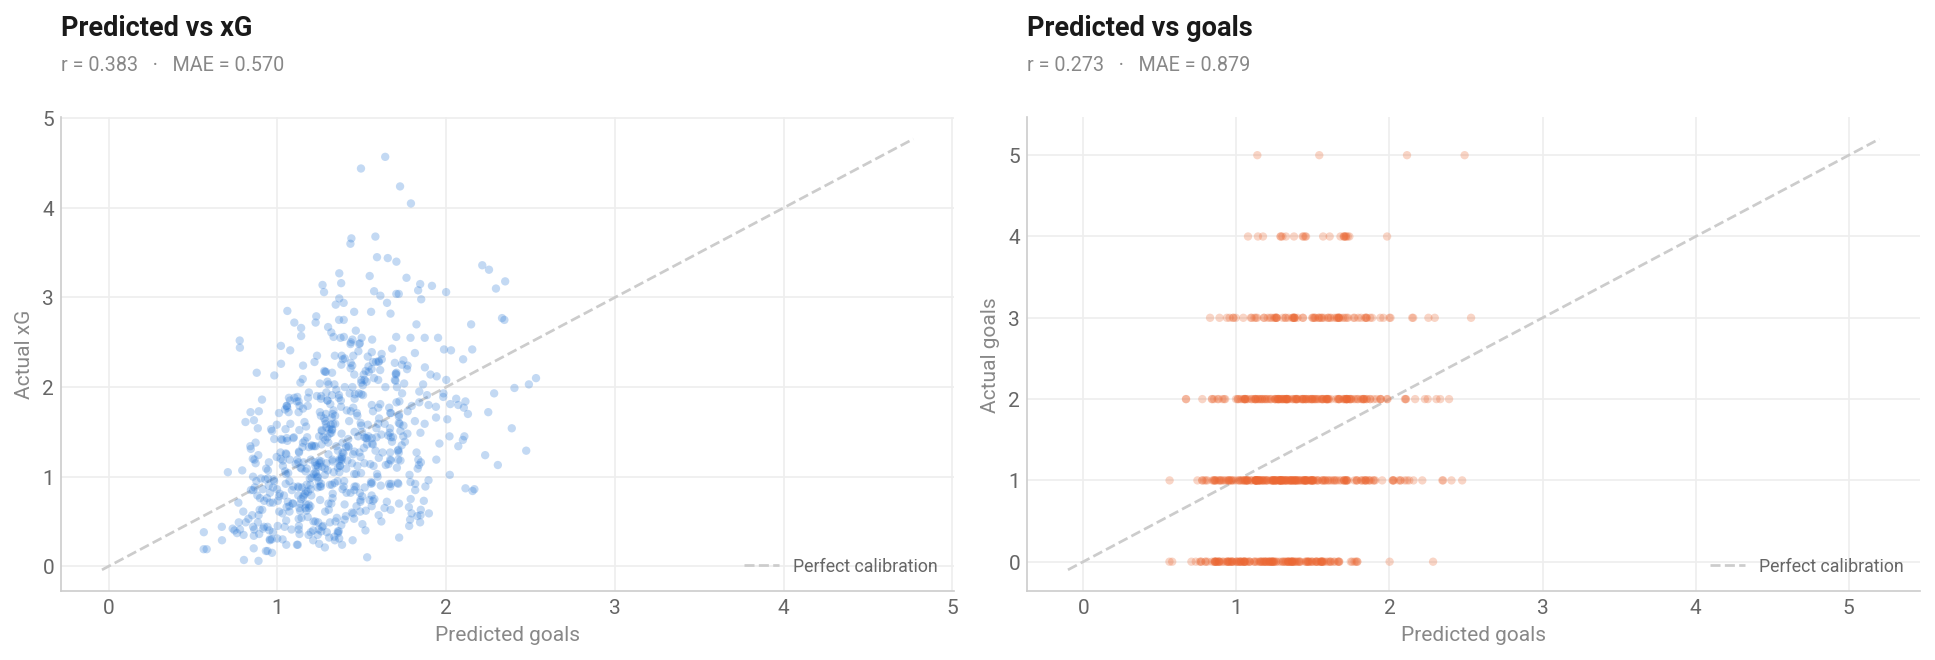

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

all_pred  = pd.concat([match['home_predicted'], match['away_predicted']])
all_xg    = pd.concat([match['home_xg'],        match['away_xg']])
all_goals = pd.concat([match['home_actual'],    match['away_actual']])

def cal_scatter(ax, pred, bench, label, color):
    ax.scatter(pred, bench, alpha=0.28, s=16, color=color, edgecolors='none', zorder=3)
    lo = min(bench.min(), pred.min()) - 0.1
    hi = max(bench.max(), pred.max()) + 0.2
    ax.plot([lo, hi], [lo, hi], '--', lw=1.3, color=C_AXIS, zorder=2, label='Perfect calibration')
    r   = np.corrcoef(bench, pred)[0, 1]
    mae = (pred - bench).abs().mean()
    ax.set_xlabel('Predicted goals', fontsize=10, color=C_MUTED)
    ax.set_ylabel(f'Actual {label}', fontsize=10, color=C_MUTED)
    _dw_title(ax, f'Predicted vs {label}', f'r = {r:.3f}   ·   MAE = {mae:.3f}', y=1.16, dy=0.07)
    ax.legend(fontsize=8.5, loc='lower right', frameon=False, labelcolor=C_INK2)
    _dw_style(ax)

cal_scatter(axes[0], all_pred, all_xg,    'xG',    C_XG)
cal_scatter(axes[1], all_pred, all_goals, 'goals', C_GOALS)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.savefig(OUT_DIR / 'v2_01_overall_calibration.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 2. Team Calibration — Scored & Conceded vs Predicted

Each dot is one team's season average. Position shows model calibration
(actual vs predicted); colour shows **xG finishing luck** — how much a team's
actual goals ran hot/cold versus the chances involved (their own xG when
scoring, the opponent's xG when conceding). Luck isn't a model error, but it
explains a lot of the scatter around the calibration line.

In [5]:
home_s = match[['home_team','home_predicted','home_actual','home_xg',
                 'away_predicted','away_actual','away_xg']].rename(columns={
    'home_team':'team','home_predicted':'sc_pred','home_actual':'sc_actual','home_xg':'sc_xg',
    'away_predicted':'co_pred','away_actual':'co_actual','away_xg':'co_xg'})
away_s = match[['away_team','away_predicted','away_actual','away_xg',
                 'home_predicted','home_actual','home_xg']].rename(columns={
    'away_team':'team','away_predicted':'sc_pred','away_actual':'sc_actual','away_xg':'sc_xg',
    'home_predicted':'co_pred','home_actual':'co_actual','home_xg':'co_xg'})
combined = pd.concat([home_s, away_s], ignore_index=True)

team_stats = combined.groupby('team').agg(
    n         = ('sc_actual', 'count'),
    sc_actual = ('sc_actual', 'mean'),
    sc_pred   = ('sc_pred',   'mean'),
    sc_xg     = ('sc_xg',     'mean'),
    co_actual = ('co_actual', 'mean'),
    co_pred   = ('co_pred',   'mean'),
    co_xg     = ('co_xg',     'mean'),
).round(3)

team_stats['sc_luck'] = team_stats['sc_actual'] - team_stats['sc_xg']  # attacking finishing luck (+ve = scored more than xG)
team_stats['co_luck'] = team_stats['co_actual'] - team_stats['co_xg']  # defensive luck (+ve = conceded more than xG)

team_stats.sort_values('sc_luck', ascending=False)

,n,sc_actual,sc_pred,sc_xg,co_actual,co_pred,co_xg,sc_luck,co_luck
team,,,,,,,,,
Aston Villa,33,1.667,1.385,1.342,1.333,1.349,1.375,0.325,-0.042
Man United,33,1.909,1.613,1.673,1.273,1.399,1.249,0.236,0.024
Man City,33,2.061,1.855,1.876,0.909,1.141,1.153,0.185,-0.244
Burnley,33,1.000,0.960,0.861,2.030,1.846,1.957,0.139,0.073
Tottenham,33,1.152,1.327,1.031,1.636,1.486,1.402,0.121,0.234
Arsenal,33,1.848,1.729,1.758,0.758,0.862,0.759,0.090,-0.001
Sunderland,33,1.091,0.957,1.020,1.333,1.457,1.483,0.071,-0.150
Nottm Forest,33,1.303,1.239,1.248,1.273,1.431,1.490,0.055,-0.217
Everton,33,1.242,1.226,1.199,1.364,1.375,1.497,0.043,-0.133


Both time_lim and iter_lim are set, faster will be used


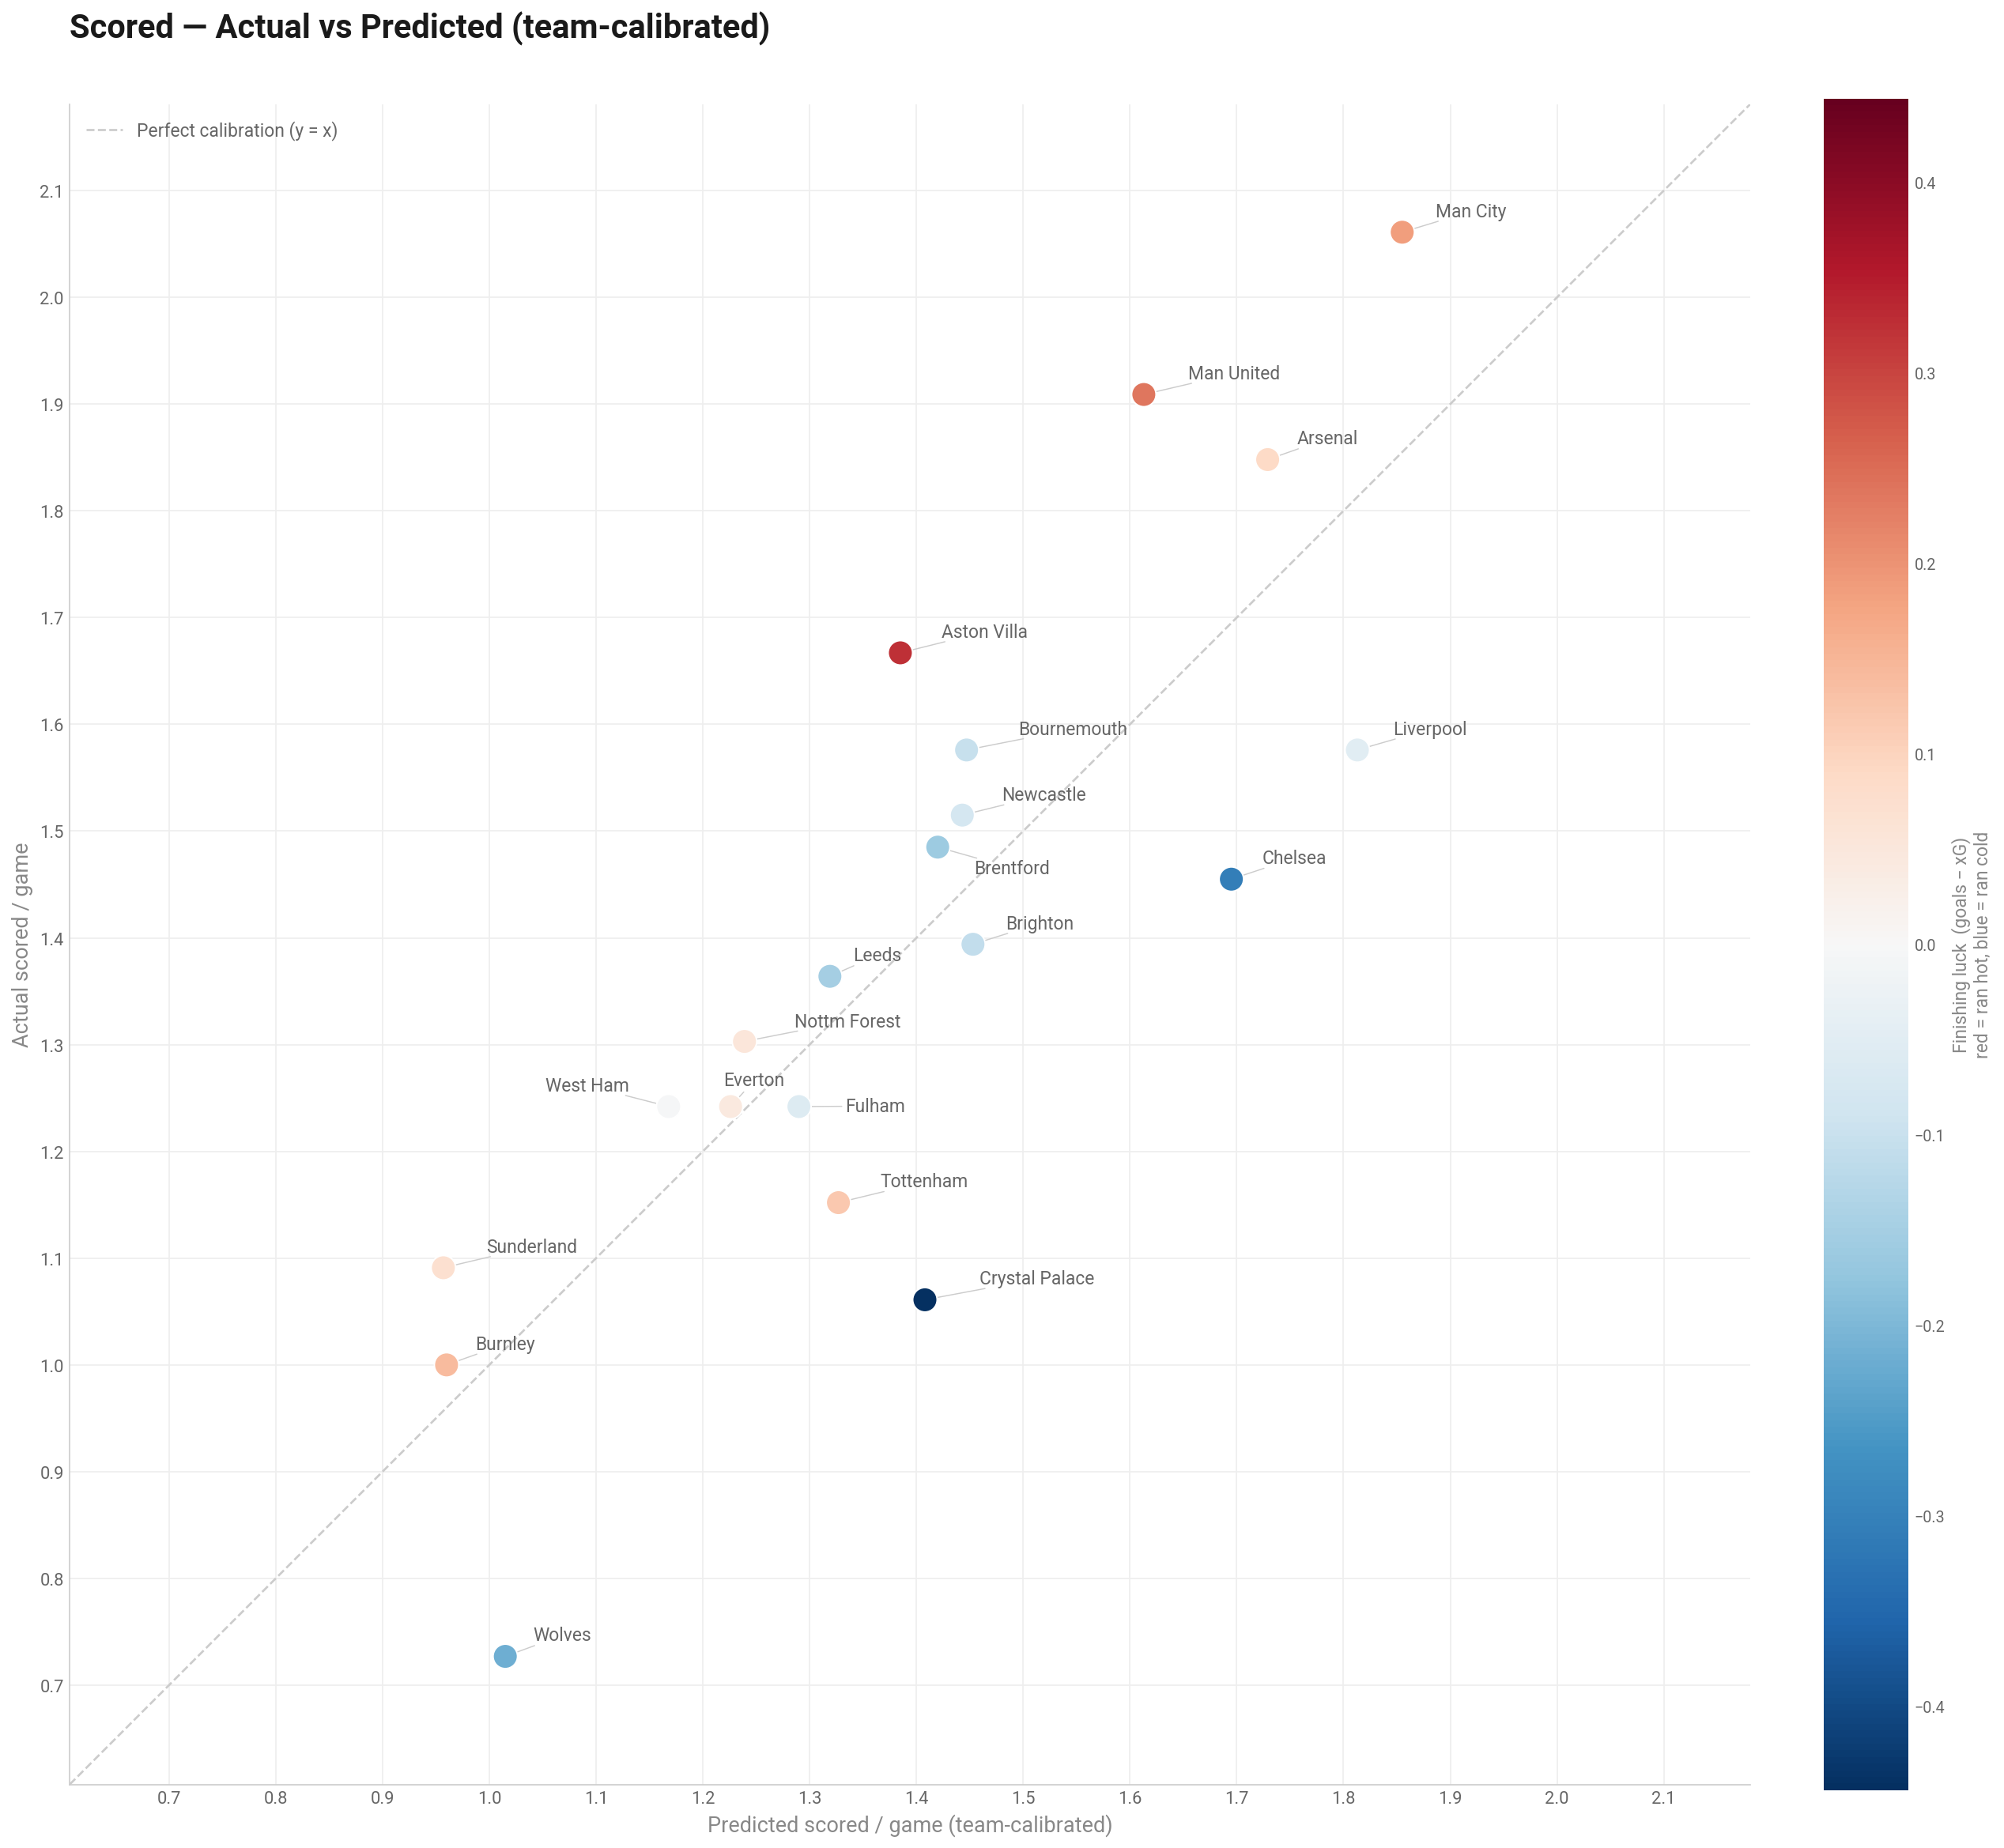

In [6]:
from adjustText import adjust_text
from matplotlib.ticker import MultipleLocator

# Full team-name labels, one chart per side, sized well beyond what's needed
# for 20 points so the dense middle cluster (most teams sit between 1.2-1.5
# goals/game) gets real physical space instead of being squeezed against
# outliers like Man City/Burnley. Finer 0.1 gridlines make that centre
# region easier to read values off directly too.

def calibration_chart(x_col, y_col, luck_col, title, cmap, xlabel, ylabel, cbar_label, out_name):
    fig, ax = plt.subplots(figsize=(17, 17))
    x = team_stats[x_col]; y = team_stats[y_col]; c = team_stats[luck_col]
    luck_max = team_stats[luck_col].abs().max()
    norm = TwoSlopeNorm(vmin=-luck_max, vcenter=0, vmax=luck_max)

    lo = min(x.min(), y.min()) - 0.12
    hi = max(x.max(), y.max()) + 0.12
    ax.plot([lo, hi], [lo, hi], '--', color=C_AXIS, lw=1.3, zorder=1, label='Perfect calibration (y = x)')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))

    sca = ax.scatter(x, y, c=c, cmap=cmap, norm=norm, s=220, edgecolors='white', linewidths=0.9, zorder=3)

    texts = [ax.text(x[team], y[team], team, fontsize=11, color=C_INK2)
             for team in team_stats.index]
    adjust_text(texts, x=x.values, y=y.values, ax=ax,
                arrowprops=dict(arrowstyle='-', color=C_AXIS, lw=0.7),
                expand=(1.8, 2.1), force_text=(0.6, 0.8), force_static=(0.4, 0.4),
                iter_lim=500, time_lim=5)

    ax.set_xlabel(xlabel, fontsize=13, color=C_MUTED)
    ax.set_ylabel(ylabel, fontsize=13, color=C_MUTED)
    _dw_title(ax, title, y=1.035, size=20)
    ax.legend(fontsize=11, frameon=False, loc='upper left', labelcolor=C_INK2)
    ax.tick_params(labelsize=10.5)
    _dw_style(ax)
    cbar = fig.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label, fontsize=11, color=C_MUTED)
    cbar.ax.tick_params(labelsize=9.5, colors=C_INK2, length=0)
    cbar.outline.set_visible(False)

    plt.tight_layout()
    plt.savefig(OUT_DIR / out_name, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

# Colour direction flips between the two charts so red always reads as
# "favourable outcome for the team": RdBu_r puts red at the high (positive)
# end for attack (scoring more than xG is good); plain RdBu puts red at the
# low (negative) end for defence (conceding less than xG is good).
# x = predicted, y = actual (standard calibration/reliability convention).
calibration_chart(
    'sc_pred', 'sc_actual', 'sc_luck', 'Scored — Actual vs Predicted (team-calibrated)', plt.cm.RdBu_r,
    'Predicted scored / game (team-calibrated)', 'Actual scored / game',
    'Finishing luck  (goals − xG)\nred = ran hot, blue = ran cold',
    'v2_02a_team_calibration_scored.png',
)

Both time_lim and iter_lim are set, faster will be used


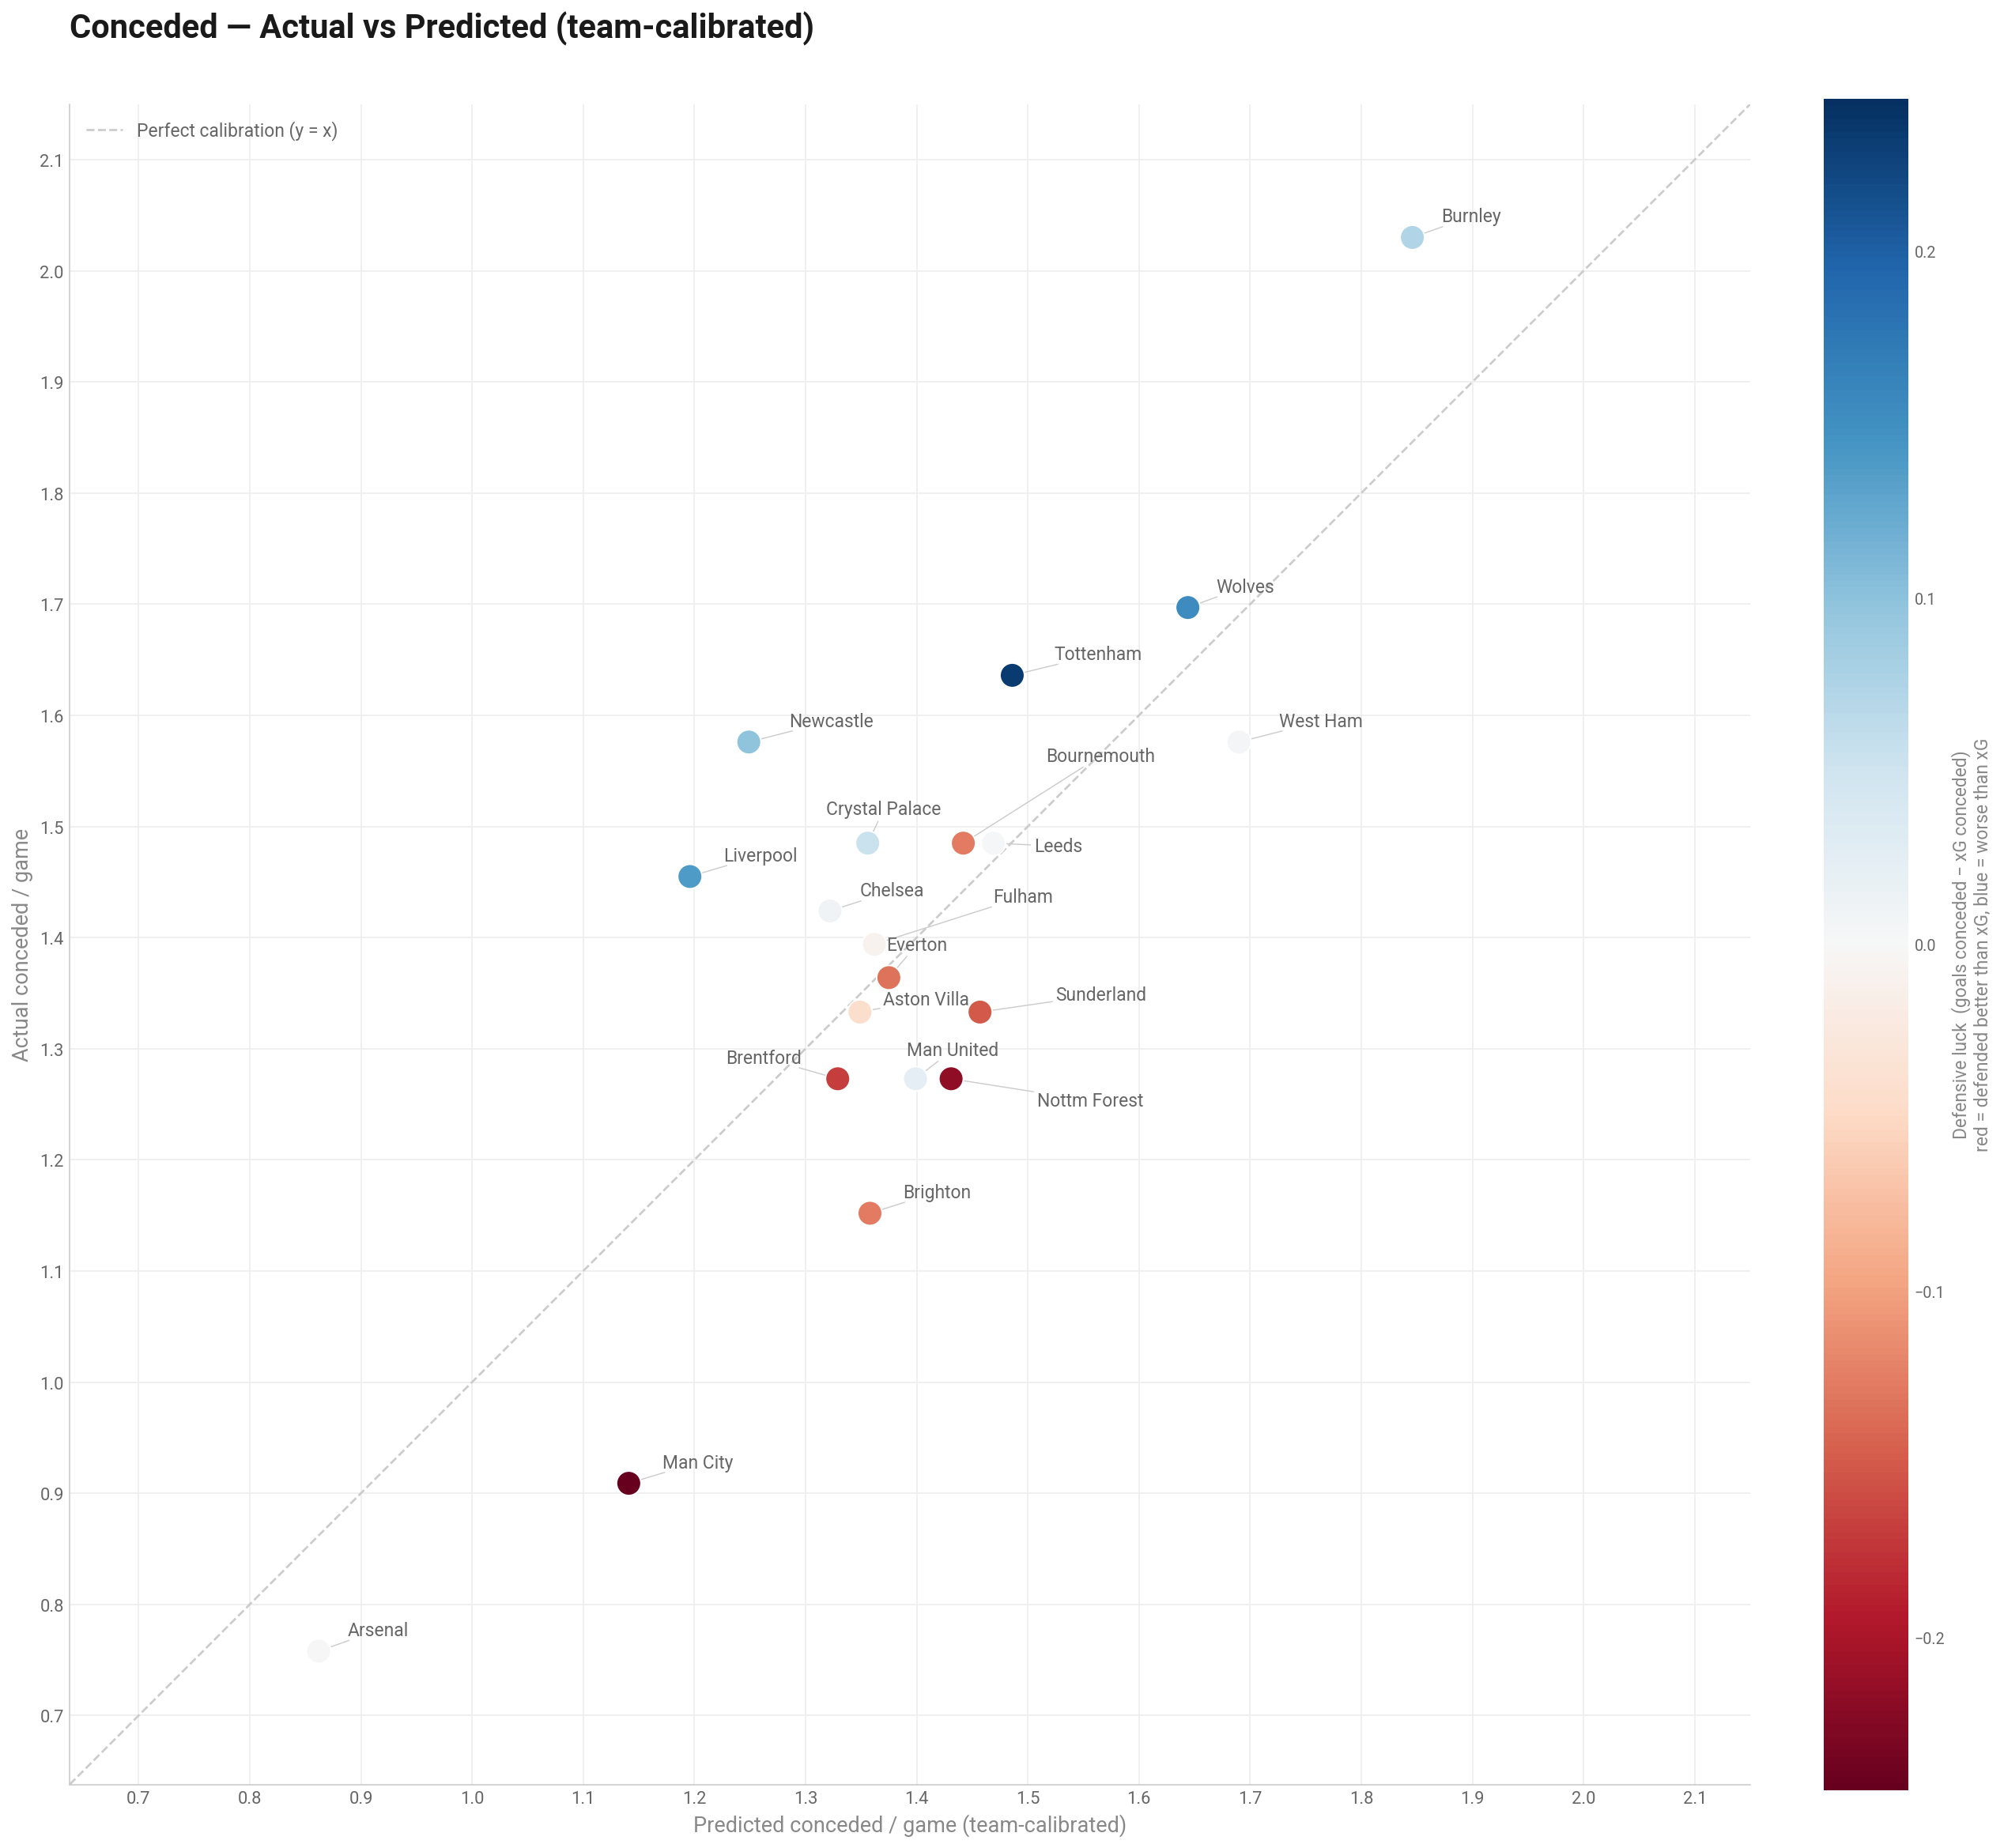

In [7]:
calibration_chart(
    'co_pred', 'co_actual', 'co_luck', 'Conceded — Actual vs Predicted (team-calibrated)', plt.cm.RdBu,
    'Predicted conceded / game (team-calibrated)', 'Actual conceded / game',
    'Defensive luck  (goals conceded − xG conceded)\nred = defended better than xG, blue = worse than xG',
    'v2_02b_team_calibration_conceded.png',
)

## 3. Historical Context — Baseline, Total Goals, Home Advantage by Season

Computed directly from final scorelines across every Premier League season on
record (not a model refit — no historical traces are saved). Since the
model's team attack/defence effects are constrained to average zero across
the league, two of its global parameters have direct descriptive proxies:

- **Baseline** ≈ average *away* goals/game (no home boost, attack/defence net to zero)
- **Home advantage** ≈ average home goals/game ÷ average away goals/game


In [8]:
conn = sqlite3.connect(DB_PATH)
hist = pd.read_sql('''
    SELECT season, home_goals, away_goals
    FROM matches
    WHERE league_id = ? AND home_goals IS NOT NULL AND away_goals IS NOT NULL
''', conn, params=[LEAGUE])
conn.close()

season_hist = hist.groupby('season').agg(
    matches       = ('home_goals', 'count'),
    avg_home      = ('home_goals', 'mean'),
    avg_away      = ('away_goals', 'mean'),
).reset_index().sort_values('season')

season_hist['total_per_match'] = season_hist['avg_home'] + season_hist['avg_away']
season_hist['baseline']        = season_hist['avg_away']
season_hist['home_adv_ratio']  = season_hist['avg_home'] / season_hist['avg_away']
season_hist['home_adv_pct']    = (season_hist['home_adv_ratio'] - 1) * 100
season_hist['home_adv_log']    = np.log(season_hist['home_adv_ratio'])

season_hist.round(3)

,season,matches,avg_home,avg_away,total_per_match,baseline,home_adv_ratio,home_adv_pct,home_adv_log
0,2021-2022,380,1.513,1.305,2.818,1.305,1.159,15.927,0.148
1,2022-2023,380,1.634,1.218,2.853,1.218,1.341,34.125,0.294
2,2023-2024,380,1.800,1.479,3.279,1.479,1.217,21.708,0.196
3,2024-2025,380,1.513,1.421,2.934,1.421,1.065,6.481,0.063
4,2025-2026,380,1.526,1.224,2.750,1.224,1.247,24.731,0.221


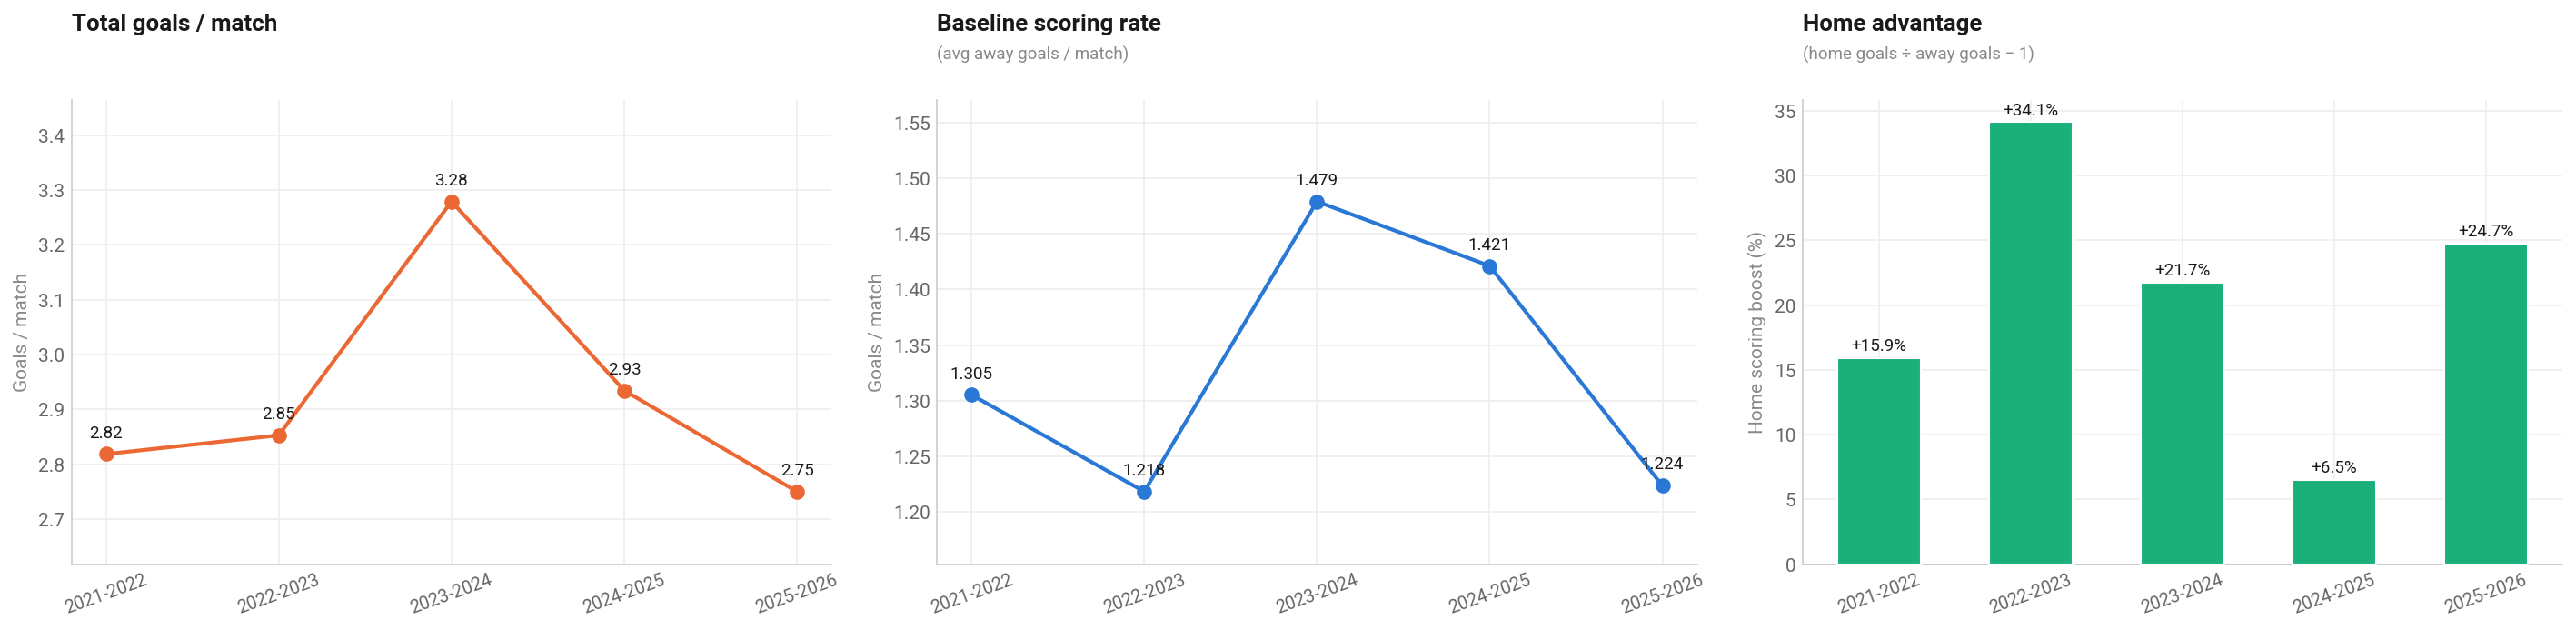

Current model priors: home_adv mu=log(1.17)=0.1570 (17.0%),  baseline mu=log(1.26)=0.2311 (1.260 goals)
Historical mean home advantage: 20.6%   |   Historical mean baseline: 1.329


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

x = np.arange(len(season_hist))
labels = season_hist['season']

ax = axes[0]
ax.plot(x, season_hist['total_per_match'], 'o-', color=C_GOALS, lw=2, markersize=7, zorder=3)
for xi, v in zip(x, season_hist['total_per_match']):
    ax.text(xi, v + 0.03, f'{v:.2f}', ha='center', fontsize=9, color=C_INK)
_dw_title(ax, 'Total goals / match', y=1.14, dy=0.06, size=12.5, sub_size=9)
ax.set_ylabel('Goals / match', fontsize=10, color=C_MUTED)
span = season_hist['total_per_match'].max() - season_hist['total_per_match'].min()
ax.set_ylim(season_hist['total_per_match'].min() - span * 0.25, season_hist['total_per_match'].max() + span * 0.35)

ax2 = axes[1]
ax2.plot(x, season_hist['baseline'], 'o-', color=C_XG, lw=2, markersize=7, zorder=3)
for xi, v in zip(x, season_hist['baseline']):
    ax2.text(xi, v + 0.015, f'{v:.3f}', ha='center', fontsize=9, color=C_INK)
_dw_title(ax2, 'Baseline scoring rate', '(avg away goals / match)', y=1.14, dy=0.06, size=12.5, sub_size=9)
ax2.set_ylabel('Goals / match', fontsize=10, color=C_MUTED)
span2 = season_hist['baseline'].max() - season_hist['baseline'].min()
ax2.set_ylim(season_hist['baseline'].min() - span2 * 0.25, season_hist['baseline'].max() + span2 * 0.35)

ax3 = axes[2]
ax3.bar(x, season_hist['home_adv_pct'], color=C_PRED, edgecolor='white', width=0.55, zorder=3)
for xi, v in zip(x, season_hist['home_adv_pct']):
    ax3.text(xi, v + (0.3 if v >= 0 else -0.6), f'{v:+.1f}%', ha='center',
              va='bottom' if v >= 0 else 'top', fontsize=9, color=C_INK)
ax3.axhline(0, color=C_AXIS, lw=1)
_dw_title(ax3, 'Home advantage', '(home goals ÷ away goals − 1)', y=1.14, dy=0.06, size=12.5, sub_size=9)
ax3.set_ylabel('Home scoring boost (%)', fontsize=10, color=C_MUTED)

for ax_ in axes:
    ax_.set_xticks(x)
    ax_.set_xticklabels(labels, fontsize=9.5, rotation=20)
    _dw_style(ax_, grid_axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(OUT_DIR / 'v2_03_historical_trends.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Current model priors: home_adv mu=log(1.17)={np.log(1.17):.4f} (17.0%),  baseline mu=log(1.26)={np.log(1.26):.4f} (1.260 goals)")
print(f"Historical mean home advantage: {season_hist['home_adv_pct'].mean():.1f}%   |   Historical mean baseline: {season_hist['baseline'].mean():.3f}")

## Data Export

In [10]:
overall.to_csv(OUT_DIR / 'v2_overall_summary.csv', index=False)
team_stats.reset_index().to_csv(OUT_DIR / 'v2_team_calibration.csv', index=False)
season_hist.round(4).to_csv(OUT_DIR / 'v2_historical_trends.csv', index=False)
print('Saved: v2_overall_summary.csv, v2_team_calibration.csv, v2_historical_trends.csv')

Saved: v2_overall_summary.csv, v2_team_calibration.csv, v2_historical_trends.csv
